# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [49]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [50]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

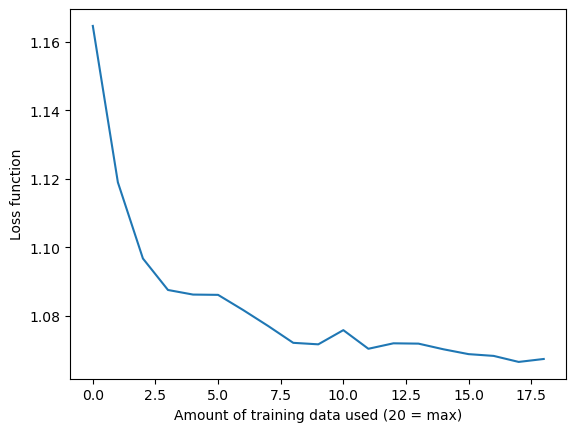

In [52]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [53]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

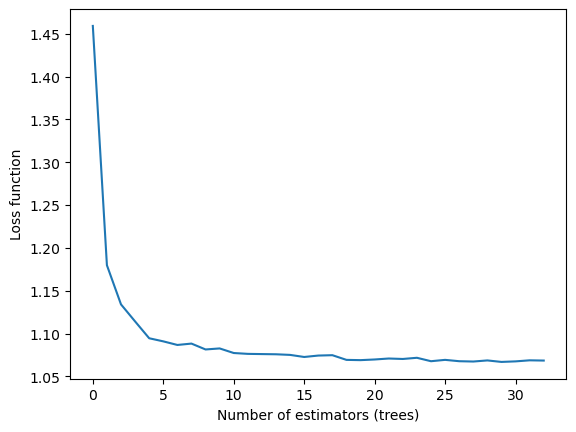

In [54]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**Response**: I would keep the first graph, amount of training data used, and cut the second graph, number of estimators. The n_estimators only says the test error falls sharply when going from 1 tree to 5 frees, then begins to flatten after 10 trees. Once reaching 30 trees, the rest of the curve will not add anything to the analysis. The training-data plot shows more of a story. It continues to decline the entire range, up to 17.5. Collecting more data looks like it would actually help with the training-data plot.

# 3. Working on your datasets

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import median_absolute_error

In [56]:
# creating a variable that will be used for both datasets for RF and 5 fold CV
# testing 10 random combinations

param_dist = {"n_estimators": [100,300], # number of trees in the forest
              "max_depth": [4, 8, 16, None], # deep each tree can go
              "min_samples_leaf": [1, 5, 20], # smallest group allowed to split down for a tree
              "max_features": ["sqrt", 1.0]} # number of features each split can look at

def fit_model(X, y, feat_columns):
  """ The training of a random forest
  X is the features, y is the values being predicted"""

  # splitting the data, 70% train, 30% test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

  # baseline, guessing training avg of ech row
  mean_pred = np.full(len(y_test), y_train.mean())
  rmse_baseline = root_mean_squared_error(y_test,mean_pred)
  print("Prediction of the mean baseline RMSE", round(rmse_baseline, 3))

  # random forest default settings
  rf = RandomForestRegressor(n_jobs=-1, random_state=0)
  rf.fit(X_train, y_train)
  prediction = rf.predict(X_test)

  rmse_default = root_mean_squared_error(y_test, prediction)
  medae_default = median_absolute_error(y_test, prediction)
  print("Default Random Forest test RMSE:", round(rmse_default, 3), "and median absolute error:", round(medae_default, 3))

  # highest feature that leans on model
  impt = pd.Series(rf.feature_importances_, index=feat_columns)
  impt = impt.sort_values(ascending=False)
  print("Top 10 feature importances")
  print(impt.head(10).round(3))

  # tuning, 5-fold cross-validation
  search = RandomizedSearchCV(
    estimator = RandomForestRegressor(n_jobs=-1, random_state=0),
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_root_mean_squared_error", 
    cv=5,
    random_state=0
  )
  search.fit(X_train, y_train)

  print("Best params:", search.best_params_)
  print("Best 5-fold cross-validation RMSE", round(-search.best_score_, 3))

  # scoring the tuned model
  best_model = search.best_estimator_
  best_prediction = best_model.predict(X_test)

  rmse_tuned = root_mean_squared_error(y_test, best_prediction)
  medae_tuned = median_absolute_error(y_test, best_prediction)
  corr = np.corrcoef(best_prediction, y_test)[0,1]

  print("Tuned Random Forest test RMSE:", round(rmse_tuned, 3),
        "| median absolute error:", round(medae_tuned, 3))
  print("Correlation(prediction, actual):", round(corr, 3))

  return y_test, best_prediction

### Streaming Movies and TV Dataset

There is no revenue column in the dataset. So, the target is TV seasons. We'll be looking at how long a show ran and if that's a longevity signal a platform care about at licensing time. The features are release_year, platform dummies, and genre flags on more than 100 TV shows. year_added_platform is excluded because over 40% of the data is missing from that column.

In [59]:
# ---------------------
# Random Forest Model
# ---------------------

movie_tv_stream = pd.read_csv("movie_tv_stream_v4.csv")

# tv_season only applies to TV shows, movies need to be filtered out
tv_stream = movie_tv_stream[movie_tv_stream["movie_or_tv_show"] == "TV Show"].copy()
tv_stream = tv_stream.dropna(subset = ["tv_season"]) # dropping rows that are missing the target

# creating platform dummies
platform_dummies = pd.get_dummies(tv_stream["channel_streaming"], prefix = "platform").astype(int)

# grabbing genres by creating lists
genre1 = list(tv_stream.columns).index("no_genre")
genre2 = list(tv_stream.columns).index("month_added_platform")
genre_total = tv_stream[list(tv_stream.columns[genre1:genre2])].sum()

# keeping only genres that appear in at least 100 TV shows, since the rare ones are almost entirely zeros and add noise without adding signal
no_uni_genres = list(genre_total[genre_total >= 100].index)

# final feature set
X_tv_stream = pd.concat([tv_stream[["release_year"]], platform_dummies, tv_stream[no_uni_genres]], axis=1)

print("The TV shows used:", len(tv_stream))

# train/test and RandomizedSeachCV
tv_y_test, tv_prediction = fit_model(X_tv_stream.values, tv_stream["tv_season"].values,
                                     list(X_tv_stream.columns))

The TV shows used: 6517
Prediction of the mean baseline RMSE 2.259
Default Random Forest test RMSE: 2.065 and median absolute error: 0.625
Top 10 feature importances
release_year     0.365
platform_Hulu    0.062
anime            0.049
reality          0.042
international    0.040
drama            0.036
family           0.034
comedy           0.024
crime            0.022
comedies         0.020
dtype: float64
Best params: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 16}
Best 5-fold cross-validation RMSE 1.934
Tuned Random Forest test RMSE: 1.995 | median absolute error: 0.618
Correlation(prediction, actual): 0.47


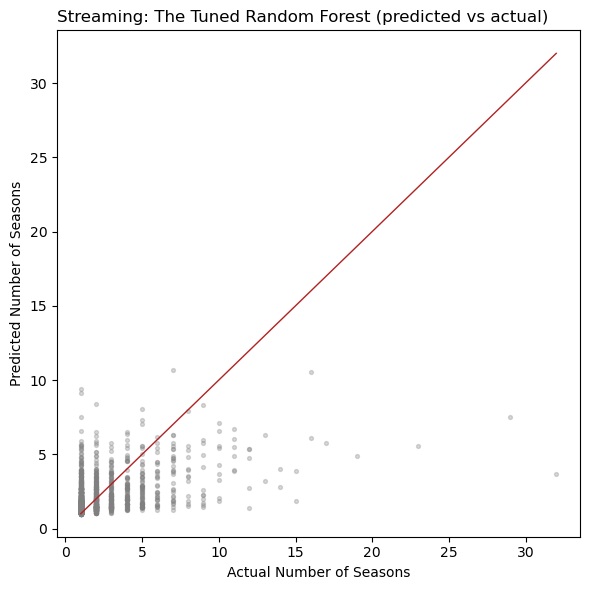

In [ ]:
# Predicted vs. Actual to check how the model performed
# each point is a TV show
plt.figure(figsize = (6, 6))
plt.scatter(tv_y_test, tv_prediction, s = 8, alpha = 0.3, color = "gray")

# Reference line
limits = [min(tv_y_test.min(), tv_prediction.min()), max(tv_y_test.max(), tv_prediction.max())]

# the closer the cloud, the better the sits on the line, the better the model's performance
plt.plot(limits, limits, color = "firebrick", linewidth = 1)
plt.xlabel("Actual Number of Seasons")
plt.ylabel("Predicted Number of Seasons")
plt.title("Streaming: The Tuned Random Forest (predicted vs actual)", loc = "left")
plt.tight_layout()
plt.show()


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

### Movie Box Office Dataset

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.